In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/listings_featured.csv")
df.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,occupancy_rate,estimated_revenue,price_per_bedroom,host_tenure_years
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,f,2,1,1,0,0.30,0.093151,2380.0,70.000000,16.602740
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,f,1,1,0,0,0.51,0.454795,24734.0,149.000000,16.550685
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,f,2,2,0,0,0.32,0.780822,117135.0,137.000000,16.468493
3,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,t,2,2,0,0,0.09,0.115068,8820.0,210.000000,16.076712
4,36299,https://www.airbnb.com/rooms/36299,20250914034649,2025-09-15,city scrape,Kew Gardens 3BR house in cul-de-sac,3 Bed House with garden close to Thames river ...,"Residential family neighborhood, with both Eng...",https://a0.muscache.com/pictures/457052/6e819d...,155938,...,f,1,1,0,0,0.64,0.112329,11480.0,93.333333,15.983562


## Exploratory Data Analysis (EDA)

This section explores pricing patterns, availability, host behavior, and demand indicators within the London Airbnb market.

The objective is to generate actionable insights for stakeholders such as hosts, investors, and platform operators.

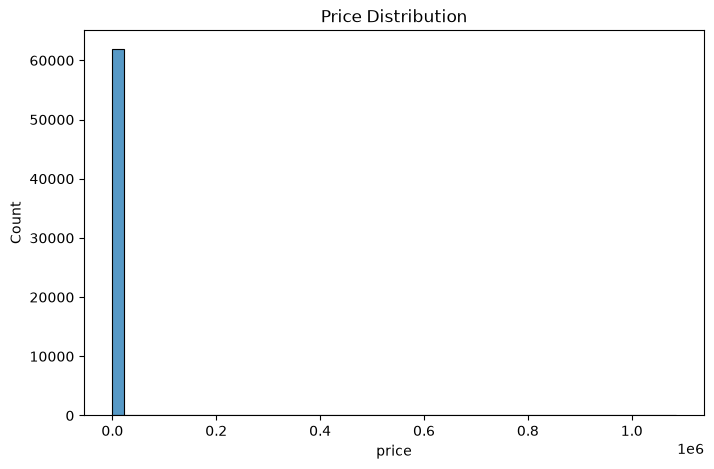

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

The distribution is heavily distorted by extreme outliers, making it difficult to interpret.

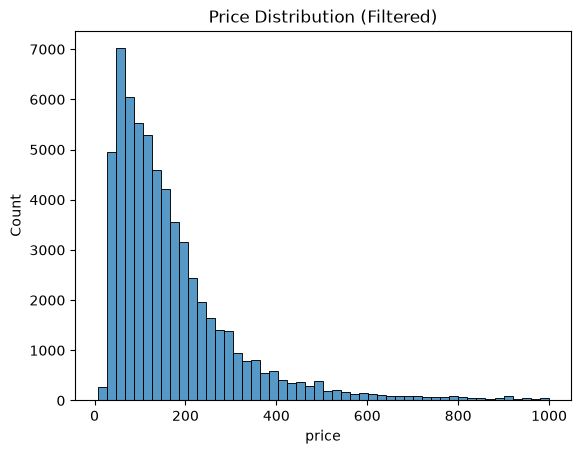

In [5]:
df_filtered = df[df['price'] < 1000]

sns.histplot(df_filtered['price'], bins=50)
plt.title("Price Distribution (Filtered)")
plt.show()

The initial visualization of price distribution is heavily skewed due to extreme outliers.

After filtering prices above 1000, the distribution becomes much clearer and reveals the typical pricing behavior of the majority of listings.

This highlights the importance of handling outliers when analyzing real-world data.

In [6]:
df['price'].describe()

count    6.196300e+04
mean     2.299170e+02
std      4.437589e+03
min      7.000000e+00
25%      7.700000e+01
50%      1.350000e+02
75%      2.210000e+02
max      1.085147e+06
Name: price, dtype: float64

### Price Distribution Analysis

The summary statistics reveal that the Airbnb pricing data is highly skewed.

The median price is 135, while the mean price is significantly higher at 229, indicating the presence of high-value outliers that distort the average.

The maximum observed price exceeds 1 million, which is far beyond the typical pricing range and suggests either luxury listings or potential data anomalies.

Additionally, the standard deviation is extremely high relative to the mean, further confirming the impact of outliers.

The interquartile range shows that 50% of listings are priced between approximately 77 and 221, indicating that most listings fall within a reasonable and concentrated price range.

These findings justify the use of filtered datasets or alternative visualizations (such as log scaling) when analyzing price distributions.

This pricing structure suggests a tiered market consisting of budget, mid-range, and premium segments.

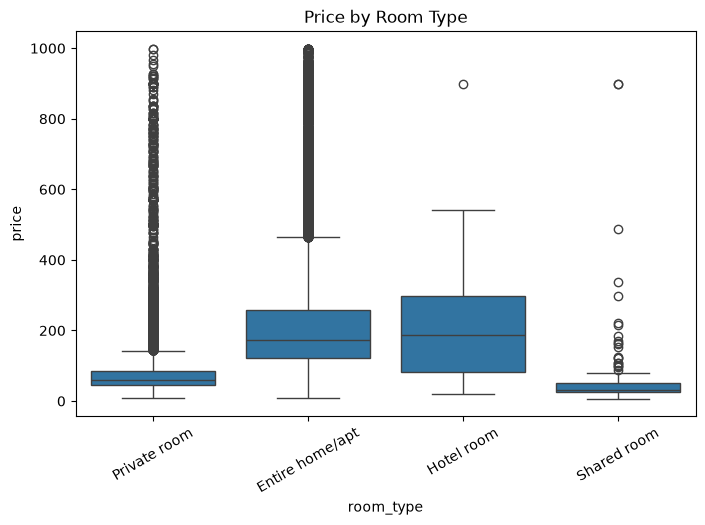

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df[df['price'] < 1000])
plt.xticks(rotation=30)
plt.title("Price by Room Type")
plt.show()


### Price by Room Type

The analysis reveals clear pricing differences across room types.

Entire homes and apartments have significantly higher median prices compared to private and shared rooms, indicating a strong premium for full property access. Hotel rooms also exhibit high median prices, suggesting they operate within a similar premium segment.

Private rooms are considerably more affordable, while shared rooms represent the lowest-priced segment in the market.

Additionally, all categories display a number of high-value outliers, indicating the presence of premium listings across different room types.

### Business Meaning:

This highlights a tiered market structure:

- Shared and private rooms cater to budget-conscious travelers
- Entire homes and hotel rooms serve the mid-to-premium segment

Hosts can price strategically based on the level of privacy and exclusivity offered. Providing an entire property allows for significantly higher pricing, while shared accommodations compete primarily on affordability.


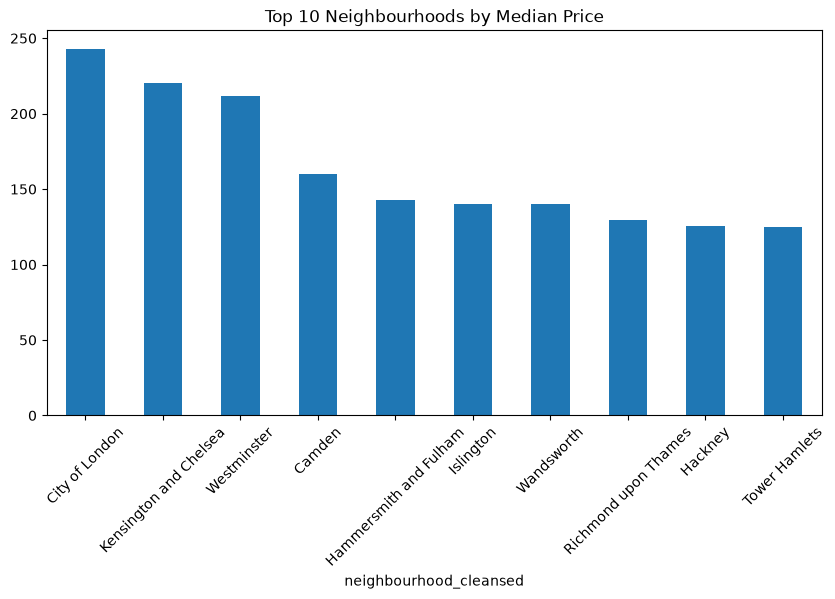

In [8]:
top_neigh = df[df['price'] < 1000] \
    .groupby('neighbourhood_cleansed')['price'] \
    .median() \
    .sort_values(ascending=False) \
    .head(10)

plt.figure(figsize=(10,5))
top_neigh.plot(kind='bar')
plt.title("Top 10 Neighbourhoods by Median Price")
plt.xticks(rotation=45)
plt.show()

### Neighbourhood Pricing Analysis

The analysis reveals significant variation in median listing prices across different neighbourhoods in London.

The City of London has the highest median price, followed closely by Kensington and Chelsea and Westminster. These areas are known for their central location, proximity to major attractions, and premium real estate markets.

In contrast, other neighbourhoods such as Islington, Wandsworth, Hackney, and Tower Hamlets exhibit lower median prices, indicating more affordable accommodation options.

### Business Meaning:

Location is a key driver of pricing in the Airbnb market. Listings in central and prestigious neighbourhoods command a premium due to higher demand from tourists and business travelers.

For investors, this suggests that properties in high-demand central areas offer higher revenue potential, while outer areas provide more affordable entry points with competitive pricing strategies.

For hosts, pricing must be adjusted based on neighbourhood positioning to remain competitive while maximizing revenue.

This indicates a clear spatial pricing gradient, where prices decrease as listings move away from central, high-demand areas.

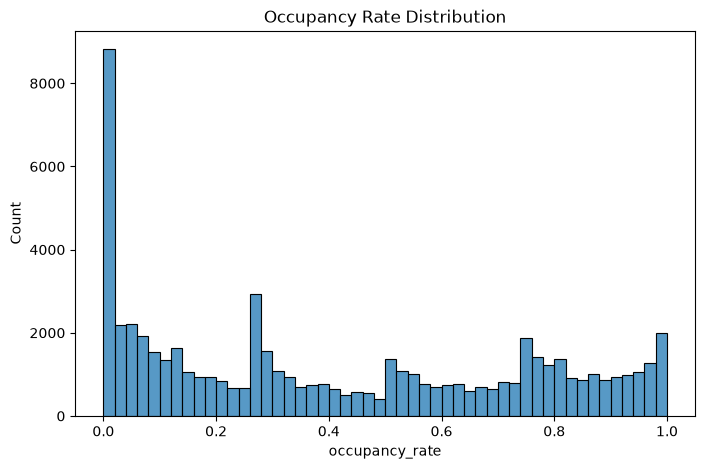

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['occupancy_rate'], bins=50)
plt.title("Occupancy Rate Distribution")
plt.show()

### Occupancy Rate Distribution

The occupancy rate distribution reveals significant variation in listing performance across the London Airbnb market.

A large proportion of listings have very low occupancy rates, indicating that many properties are either infrequently booked or remain available for most of the year.

At the same time, there are listings with high occupancy rates, suggesting strong demand for certain properties.

The distribution also shows clustering at different occupancy levels, which may reflect varying hosting strategies such as full-time rentals, seasonal availability, or occasional hosting.

### Business Meaning:

This highlights the uneven nature of demand in the Airbnb market.

Some listings consistently attract bookings and generate high revenue, while many struggle to maintain occupancy.

Hosts should focus on improving listing quality, pricing, and location advantages to increase occupancy, while investors should prioritize properties with strong demand indicators.

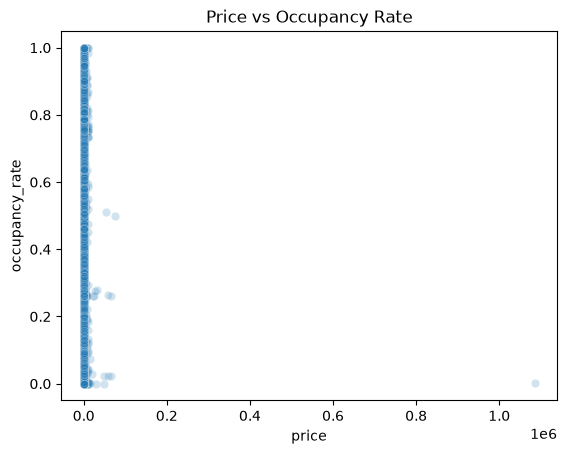

In [10]:
sns.scatterplot(x='price', y='occupancy_rate', data=df, alpha=0.2)
plt.title("Price vs Occupancy Rate")
plt.show()

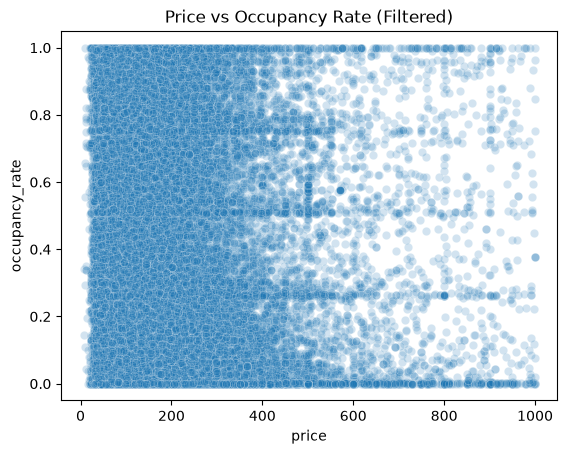

In [11]:
df_filtered = df[df['price'] < 1000]

sns.scatterplot(x='price', y='occupancy_rate', data=df_filtered, alpha=0.2)
plt.title("Price vs Occupancy Rate (Filtered)")
plt.show()

### Price vs Occupancy Relationship

The initial scatter plot was distorted by extreme price outliers, which compressed the majority of data points into a narrow range.

After filtering out prices above 1000, the relationship between price and occupancy becomes clearer.

The scatter plot shows that there is no strong linear relationship between price and occupancy rate. Listings with both high and low prices exhibit a wide range of occupancy outcomes.

### Business Meaning:

This suggests that pricing alone does not determine booking performance.

Instead, other factors such as location, property type, amenities, and review quality likely play a significant role in influencing demand.

Hosts should therefore adopt a holistic strategy, combining competitive pricing with quality improvements to maximize occupancy.

There appears to be high variability in occupancy across all price levels, indicating a highly competitive and heterogeneous market.

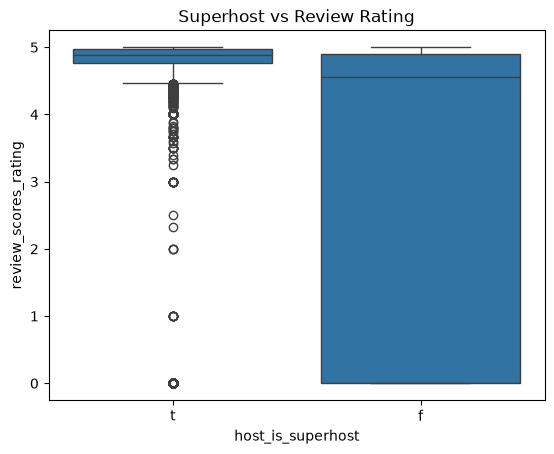

In [12]:
sns.boxplot(x='host_is_superhost', y='review_scores_rating', data=df)
plt.title("Superhost vs Review Rating")
plt.show()

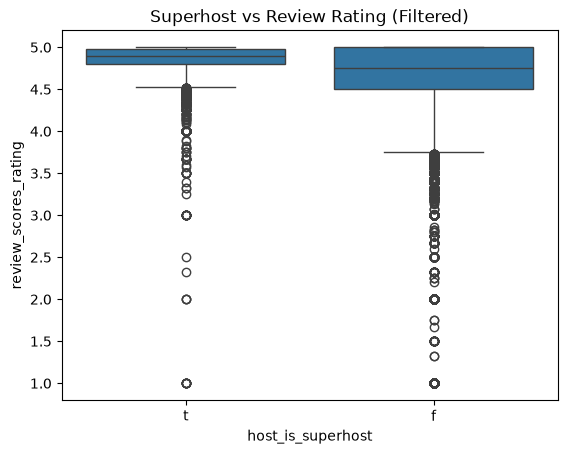

In [13]:
df_rated = df[df['review_scores_rating'] > 0]

sns.boxplot(x='host_is_superhost', y='review_scores_rating', data=df_rated)
plt.title("Superhost vs Review Rating (Filtered)")
plt.show()


### Superhost vs Review Rating

The initial analysis showed a large number of zero ratings for non-superhost listings. Upon further inspection, these values correspond to listings without reviews rather than actual low scores.

After filtering out unrated listings, the comparison becomes more meaningful.

Superhosts consistently achieve slightly higher review scores compared to non-superhosts, and their ratings are more tightly distributed near the maximum.

### Business Meaning:

This suggests that superhost status is associated with higher service quality and better guest experiences.

Hosts who maintain consistent quality, responsiveness, and reliability are more likely to achieve higher ratings and earn the superhost designation.

For new hosts, improving service quality can lead to higher ratings and increased demand over time.

The variability among non-superhosts indicates inconsistent service quality across listings.

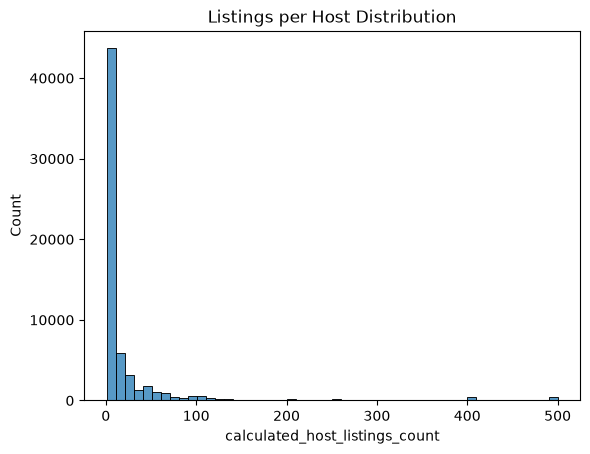

In [14]:
sns.histplot(df['calculated_host_listings_count'], bins=50)
plt.title("Listings per Host Distribution")
plt.show()

### Host Listing Distribution

The distribution of listings per host is highly right-skewed.

The vast majority of hosts manage only one or two listings, indicating that most participants in the market are casual or individual hosts.

However, a small number of hosts manage a large number of listings, with some operating hundreds of properties.

### Business Meaning:

This reveals a dual market structure:

- A large base of individual hosts offering occasional or small-scale rentals
- A small group of professional operators dominating a significant portion of supply

This distribution resembles a power-law pattern, commonly observed in platform economies where a small number of participants control a disproportionately large share of resources.